<a href="https://colab.research.google.com/github/Demosthene-OR/Student-AI-and-Data-Management/blob/main/33_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<img src="https://prof.totalenergies.com/wp-content/uploads/2024/09/TotalEnergies_TPA_picto_DegradeRouge_RVB-1024x1024.png" height="150" width="150">

<hr style="border-width:2px;border-color:#75DFC1">
<h1 style = "text-align:center" >Introduction au Réseau neuronal convolutif avec Keras</h1> 
<h3 style = "text-align:center" >Prédiction à l'aide des <i>Convolutional Neural Networks</i> (CNN)</h3>
<hr style="border-width:2px;border-color:#75DFC1">


## Contexte et objectif

> Le principal objectif de l'exercice est d'apprendre à construire un réseau de neurones convolutif (*Convolutional Neural Network - CNN*) à l'aide du package **Keras**, et de montrer en quoi cette architecture est plus adaptée à certains problèmes de classification.
>
> La **principale différence** entre les réseaux classiques et les réseaux de neurones convolutifs réside dans le **type d'entrée** et dans la **transition entre les couches**. 
>
> Les CNN ont été construits pour traiter de la donnée de type **image**. Les couches de convolution sont aujourd'hui vues comme les **meilleurs extracteurs de features** pour des problèmes de classification liés à l'image.
>
>
> Nous allons construire un réseau de neurones convolutif comprenant plusieurs types de couches: des couches de **convolution** ainsi que des couches de **pooling** et de **dropout** pour régulariser notre modèle. 

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1>1. Les différentes couches qui constituent un CNN</h1></center>
<hr style="border-width:2px;border-color:#75DFC1">


## Couches de Convolution


>Les couches de convolution sont très utilisées pour la classification d'images. Avant d'aborder directement les opérations effectuées par une couche de convolution, il est important de comprendre l'opération à la base du neurone de cette couche, le **produit de convolution**.
>
>Le produit de convolution est une opération qui ressemble beaucoup au produit scalaire, sauf qu'il ne s'effectue pas sur un vecteur mais sur une matrice :
>
>D'un côté nous avons une matrice d'entrée, souvent appelée **tuile** ou *convolution patch* en anglais, et d'un autre nous avons une matrice de convolution, souvent appelée **noyau de convolution**, **filtre** ou *convolution kernel* en anglais.
>
>Ces deux matrices **doivent absolument avoir les mêmes dimensions** pour calculer leur produit de convolution.
>
>Les étapes du produit de convolution sont les mêmes que celles du produit scalaire:
>
>* Produit terme à terme des deux matrices.
>* Somme des produits.
>
>Dans la figure interactive suivante, nous illustrons la convolution d'une image de dimensions  4 x 4  par un noyau de convolution de dimensions  3 x 3 :
>
>* Etape 1: Découpage de l'image en plusieurs tuiles convolables. Chaque tuile a une couleur différente.
>* Etape 2: Produits de convolutions entre chaque tuile et le noyau.
>* Etape 3: Activation et concaténation des produits en une nouvelle matrice.

* **(a)** Exécuter la cellule suivante pour comprendre le déroulement d'un produit de convolution.





In [1]:
%matplotlib inline
from interaction_cnn import show_operation_conv
show_operation_conv()


Figure(animation_duration=1000, background_style={'fill': 'white'}, fig_margin={'top': 60, 'bottom': 60, 'left…


>Pour quelle raison faisons-nous cette opération? Quels sont les avantages à utiliser cette technique?
>
>La convolution d'une image est en réalité très facilement interprétable.
>
>Dans la figure interactive suivante, nous illustrons la convolution d'une photo du Taj-Mahal par un noyau de convolution de dimensions  3 x 3.
>
>La photo est en noir et blanc pour qu'elle corresponde à une matrice de pixels simple, mais l'opération peut être réalisée sur les matrices des composantes rouges, vertes et bleues d'une photo en couleur.

* Pour interagir avec cette figure, vous pouvez soit séléctionner un des noyaux de convolutions de la liste, soit modifier manuellement les coefficients du noyau.



In [7]:
from interaction_cnn import show_conv
show_conv()


RadioButtons(options=('Identity', 'Contrast', 'Edge Detection', 'Vertical Edge Detection', 'Horizontal Edge De…


>Ainsi, la convolution d'une image peut être vue comme une extraction de features. Par exemple, les noyaux servant à détecter les bords pourraient être utiles pour classifier certaines formes géométriques.
>
>L'intérêt des neurones de convolution est que par l'entraînement ils pourront trouver eux-mêmes les meilleurs noyaux de convolution à utiliser pour extraire des features à partir d'une image.
>



## Couches de Max-Pooling



>Les couches de Max-Pooling sont utilisées lorsque les données sur lesquelles nous travaillons sont des matrices. Le concept du max-pooling est très simple:
>
>La matrice est **découpée en plusieurs petites tuiles** contenant des valeurs de la matrice.
De chaque tuile on extrait **la valeur maximale**.
On **recompose une matrice** ne contenant que les valeurs maximales de chaque tuile.
Nous avons illustré l'opération de max-pooling avec une taille de tuile 2x2 dans la figure interactive suivante. La matrice contient des valeurs représentées par la couleur bleue. Plus la cellule de la matrice est claire, plus sa valeur est élevée.
>

* **(b)** Exécuter la cellule suivante pour afficher une figure interactive illustrant le max-pooling
>Pour interagir avec cette figure, cliquer sur le bouton Next pour aller à l'étape suivante et Previous pour aller à l'étape précédente. Le bouton Shuffle Colors vous permet de changer au hasard les valeurs de la matrice.



In [8]:
from interaction_cnn import show_maxpool
show_maxpool()


Figure(animation_duration=1000, background_style={'fill': 'white'}, fig_margin={'top': 60, 'bottom': 60, 'left…

Button(description='Shuffle Colors', style=ButtonStyle())


> Les couches de pooling permettent notamment de **diminuer la résolution** de la sortie de la convolution, dans le but de diminuer le nombre d'opérations effectuées et le nombre de paramètres du modèle. Elles permettent également de trouver des motifs plus larges que la taille du kernel de la convolution puisqu'elles combinent les informations extraites de plusieurs zones adjacentes.

## Couches de Dropout
>La technique du Dropout (ou Abandon en français) consiste à **couper certaines connexions entre neurones** de couches **consécutives**. Cette technique réduit considérablement la quantité de paramètres à entraîner et permet de "renforcer" les liens entre neurones consécutifs.
>
>Le **paramètre p** donne la proportion de connexions qui seront **coupées**. Chaque couche de dropout d'un modèle est définie par ce paramètre.
>
>Dans la figure interactive suivante, nous illustrons deux couches de dropout entre 3 couches denses. La première va garder 4/5 des connexions tandis que la deuxième va en garder 2/3.

* **(c)** Exécuter la cellule suivante pour afficher la figure interactive.



In [9]:
from interaction_cnn import show_dropout
show_dropout()


Figure(animation_duration=1000, background_style={'fill': 'white'}, fig_margin={'top': 60, 'bottom': 60, 'left…


> Nous allons à présent utiliser les notions abordées ci-dessus sur l'exemple de la base de données **MNIST**. Nous allons implémenter un réseau de neurones convolutifs pour résoudre un problème de classification des images (chiffres) de la base de données.
>
>
* **(d)** Exécuter la cellule suivante pour importer les packages nécessaires.



In [10]:
%matplotlib inline
import numpy as np

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from keras.utils import to_categorical

from sklearn import metrics

import matplotlib.pyplot as plt
from matplotlib import cm

import itertools



* **(e)** Recupérer les données d'entraînements et de test en exécutant la cellule suivante.



In [11]:
# Pour importer le datasets mnist de Keras
from tensorflow.keras.datasets.mnist import load_data

# Chargement des données MNIST
(X_train, y_train), (X_test, y_test) = load_data()

# Changer la forme de X_train et X_test
X_train = X_train.reshape([-1, 28*28])
X_test = X_test.reshape([-1, 28*28])

# Shape of X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:',y_train.shape)


Shape of X: (60000, 784)
Shape of y: (60000,)



> De manière générale les images en couleurs sont composées de 3 canaux Rouge/Vert/Bleu de 28x28 pixels superposés les uns sur les autres. Nos images étant en niveaux de gris, elles n'ont qu'un seul canal (profondeur = 1).

* **(f)** Transformer les données **`X_train`** en un tableau à 4 dimensions (nb_images, largeur, hauteur, profondeur). Chacune des images sera ainsi redimensionnée au format (28,28,1). Faire de même pour les données **`X_test`**.



In [ ]:
## Insérez votre code ici


In [12]:
X_train = X_train.reshape((-1, 28, 28, 1))

X_test = X_test.reshape((-1, 28, 28, 1))

X_train.shape #Vérification des dimensions de l'ensemble d'entrainement


(60000, 28, 28, 1)


* **(g)** Diviser les pixels des données **`X_train`** et **`X_test`** par 255 afin qu'ils soient compris entre 0 et 1.


* **(h)** Transformer les labels de **`y_train`** et **`y_test`** en vecteurs catégoriels binaires (*one hot*), grâce à la fonction `to_categorical` du sous-module `np_utils` de `keras`.



In [ ]:
## Insérez votre code ici


In [13]:
X_train = X_train / 255
X_test = X_test / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)



<hr style="border-width:2px;border-color:#75DFC1">
<center><h1>2. Construction de l'architecture CNN </h1></center>
<hr style="border-width:2px;border-color:#75DFC1">


> On rappelle qu'un neurone de convolution contient un noyau avec lequel il effectue le produit de convolution avec les différents *patchs* de l'image.
>
> Dans une couche de neurones de convolution, chaque neurone possède son propre noyau de convolution. L'entraînement de cette couche consiste à trouver les noyaux les plus performants pour la classification.
>
> En général, les couches de convolution sont suivies par des couches de *pooling* afin de réduire progressivement la dimension de l'entrée. Ceci permet à la fois de régulariser le modèle (en diminuant les risques d'overfitting) et d'améliorer la performance de l'algorithme en termes de temps de calcul et d'utilisation de mémoire.
>
> Pour ajouter une couche de convolution à un modèle séquentiel, il suffit comme pour les couches denses de l'instancier avec le constructeur correspondant. Pour les couches de convolution, il s'agit du constructeur **`Conv2D`** qui contient différents paramètres:
>
> * **filters** : Un entier correspondant au nombre de matrice de convolution dans la couche.
>
> * **kernel_size** : Un couple d'entiers correspondant aux dimensions du noyau de convolution.
>
> * **padding** : détermine si le noyau a le droit de dépasser le bord de l'image.
>
> * **input_shape** : n-uplet correspondant aux dimensions de l'image d'entrée. Doit absolument être précisé dans la première couche.
>
>* **data_format** : détermine quelle dimension de l'input correspond à quelle dimension de l'image.
>
> * **activation** : fonction d'activation qui sera appliquée à chaque case de la sortie du neurone.

> Une architecture CNN a habituellement l'aspect suivant : 

<img src="https://assets-datascientest.s3-eu-west-1.amazonaws.com/train/lenet.png" style="width:auto; height:250px" />

## Création et entraînement du modèle 


* **(a)** Instancier une couche d'input prenant comme argument **`shape`** = (28,28,1).


* **(b)**  Instancier une couche de convolution appelée **first_layer** à l'aide du constructeur `Conv2D` avec les paramètres suivants:
    ``` python 
    filters = 32  #La couche sera composée de 32 matrices de convolution.   
    kernel_size = (5, 5) #le noyau de convolution sera de dimension 5x5 (25 coefficients par filtre).
    padding = 'valid'  #pour que le noyau ne puisse pas dépasser les bords de l'image.   
    activation = 'relu'.
    ```
    
* **(c)** Instancier une couche de *max-pooling* appelé **second_layer** à l'aide du constructeur `MaxPooling2D` avec le paramètre `pool_size = (2, 2)` pour que le maximum soit calculé sur des morceaux de dimensions 2x2.


* **(d)** Ajouter les couches au modèle. Il faudra les ajouter dans l'ordre.



In [ ]:
## Insérez votre code ici


In [14]:
inputs = Input(shape = (28, 28,1), name = "Input")

first_layer = Conv2D(filters = 32,
                     kernel_size = (5, 5),
                     padding = 'valid',
                     activation = 'relu')

second_layer = MaxPooling2D(pool_size = (2, 2))



x=first_layer(inputs)
x=second_layer(x)




* **(e)** Instancier une couche de *dropout* appelée **third_layer** à l'aide du constructeur `Dropout` avec le paramètre `rate = 0.2` pour couper 20% des connexions entre la couche précédente et la couche suivante.


* **(f)** Instancier une couche d'applatissement appelée **fourth_layer** à l'aide du constructeur `Flatten`. Cette couche ne prend pas de paramètre et permet juste d'aplatir une matrice en un vecteur. Cette transformation est nécessaire pour la suite car les couches denses ne prennent que des vecteurs en entrée et non des matrices.


* **(g)** Instancier une couche dense appelée **fifth_layer** à l'aide du constructeur `Dense` avec 128 neurones et la fonction d'activation *ReLU*.



* **(h)** Instancier une couche dense appelée **output_layer** avec 10 neurones (pour 10 classes d'output) et une fonction d'activation *softmax* pour renvoyer des prédictions de probabilité pour chaque classe.  
 
 
* **(i)** Ajouter toutes ces couches au modèle.



In [ ]:
## Insérez votre code ici


In [15]:
third_layer = Dropout(rate = 0.2)

fourth_layer = Flatten()

fifth_layer = Dense(units = 128,
                    activation = 'relu')

output_layer = Dense(units = 10,
                     activation='softmax')

x=third_layer(x)
x=fourth_layer(x)
x=fifth_layer(x)

outputs=output_layer(x)



model = Model(inputs = inputs, outputs = outputs)



* **(j)** Compiler le modèle en utilisant la fonction de perte **`'categorical_crossentropy'`**, l'algorithme de descente de gradient **`'adam'`** comme `optimizer`, ainsi que la métrique  **`['accuracy']`**. 


* **(k)** Entraîner le modèle avec les données d'entraînement sur 10 *epochs*, des *batchs* de taille 200 et un *split* de test de 0,2. Stocker la sortie de l'entraînement dans une variable nommée **training_history**.



In [ ]:
## Insérez votre code ici


In [16]:
model.compile(loss='categorical_crossentropy', # fonction de perte
              optimizer='adam',                # algorithme d'optimisation
              metrics=['accuracy'])            # métrique d'évaluation

training_history = model.fit(X_train, y_train,
                             validation_split = 0.2,
                             epochs = 10,
                             batch_size = 200)


Epoch 1/10
240/240 [==============================] - 10s 5ms/step - loss: 0.2735 - accuracy: 0.9237 - val_loss: 0.1028 - val_accuracy: 0.9718
Epoch 2/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0872 - accuracy: 0.9742 - val_loss: 0.0665 - val_accuracy: 0.9813
Epoch 3/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0586 - accuracy: 0.9825 - val_loss: 0.0612 - val_accuracy: 0.9818
Epoch 4/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0458 - accuracy: 0.9855 - val_loss: 0.0498 - val_accuracy: 0.9843
Epoch 5/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0384 - accuracy: 0.9880 - val_loss: 0.0469 - val_accuracy: 0.9871
Epoch 6/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0315 - accuracy: 0.9902 - val_loss: 0.0470 - val_accuracy: 0.9863
Epoch 7/10
240/240 [==============================] - 1s 3ms/step - loss: 0.0254 - accuracy: 0.9918 - val_loss: 0.0418 - val_accuracy: 0.9880
Epoch


<hr style="border-width:2px;border-color:#75DFC1">
<center><h1>3. Performances du modèle CNN </h1></center>
<hr style="border-width:2px;border-color:#75DFC1">


* **(a)** Lancer la cellule suivante pour stocker les précisions d'entraînement et de test obtenues pendant l'entraînement.



In [17]:
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']



* **(b)** Tracer l'évolution des précisions tout au long de l'entraînement.



In [ ]:
## Insérez votre code ici


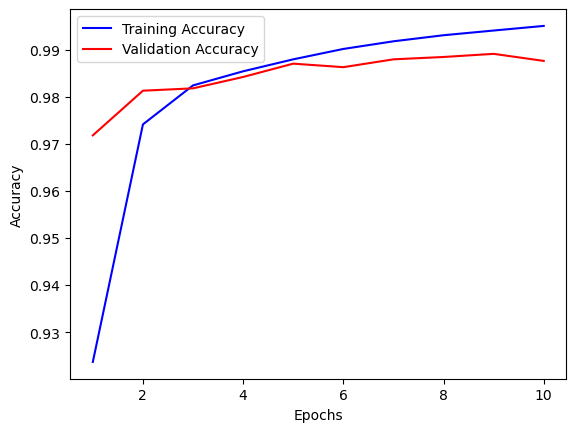

In [18]:
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 11, 1),
         training_history.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 11, 1),
         training_history.history['val_accuracy'], 
         label = 'Validation Accuracy',
         color = 'red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()



* **(c)** Prédire les classes de l'échantillon **X_test** à l'aide de la méthode `predict` du modèle. Stocker le résultat dans un tableau nommé **test_pred**.


* **(d)** Appliquer la méthode `argmax` sur les tableaux **test_pred** et **y_test** pour obtenir des vecteurs d'entiers correspondant aux classes prédites et réelles. Il faudra passer l'argument '`axis = 1`' pour que l'argmax soit calculée sur les colonnes et non les lignes. Stocker les sorties des appels de la méthode `argmax` dans des tableaux nommés **test_pred_class** et **y_test_class**.


* **(e)** Afficher un compte-rendu évaluatif détaillé de la perfomance du modèle grâce à la fonction `classification_report` du sous-module **metrics** de **scikit-learn**.



In [ ]:
## Insérez votre code ici


In [19]:
test_pred = model.predict(X_test)

test_pred_class = test_pred.argmax(axis = 1)
y_test_class = y_test.argmax(axis = 1)

print(metrics.classification_report(y_test_class, test_pred_class))


313/313 [==============================] - 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




> La perfomance de notre modèle est encore plus robuste que celle du modèle dense de l'exercice précédent. La précision est maintenant de 99%, soit 4% de plus que le modèle précédent.


* **(f)** Calculer et afficher la matrice de confusion entre **y_test_class** et **test_pred_class**, appelée **cnf_matrix**, grâce à la fonction `confusion_matrix` du sous-module **metrics** de **scikit-learn**. 



In [ ]:
## Insérez votre code ici


[[ 974    0    0    0    0    1    1    1    2    1]
 [   0 1131    0    0    0    0    0    2    1    1]
 [   2    2 1013    1    0    0    1    7    5    1]
 [   0    0    4 1001    0    2    0    0    2    1]
 [   0    0    0    0  970    0    0    0    1   11]
 [   2    0    0    7    0  880    2    0    0    1]
 [   4    3    0    0    2    2  946    0    1    0]
 [   0    0    4    2    0    0    0 1021    1    0]
 [   3    0    2    0    0    0    1    3  959    6]
 [   0    0    0    1    3    2    0    2    1 1000]]


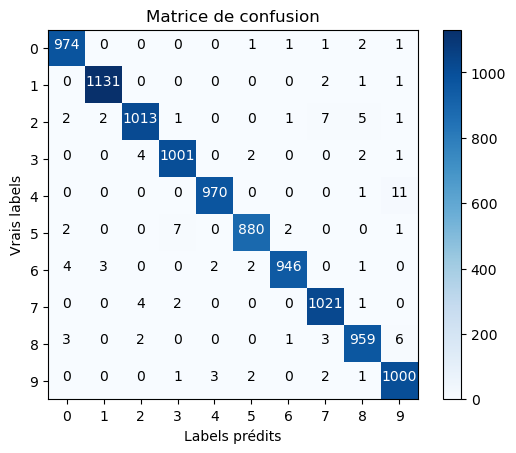

In [20]:
#Réponse valable:
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
print(cnf_matrix)

###Optionnel: Afficher une matrice de confusion sous forme de tableau coloré
classes = range(0,10)

plt.figure()

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Matrice de confusion")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment="center",
             color="white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()



> Le modèle a toujours un peu de mal avec les chiffres 3 et 5, mais si on regarde les images sur lesquelles le modèle s'est trompé, il devient difficile de lui en vouloir.

* **(g)** Lancer la cellule suivante pour afficher des images sur lesquelles le modèle s'est trompé. Vous pouvez la relancer plusieurs fois pour afficher d'autres images.



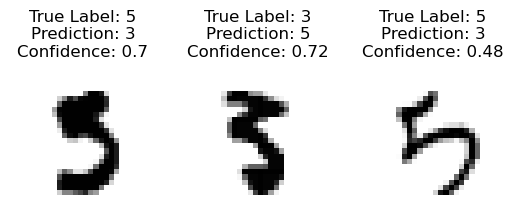

In [21]:
error_indexes = []
for i in range(len(test_pred)):
    if (test_pred_class[i] != y_test_class[i]):
        if(y_test_class[i] == 5 or y_test_class[i] == 3):
            if(test_pred_class[i] == 5 or test_pred_class[i] == 3):
                error_indexes += [i]

j = 1
for i in np.random.choice(error_indexes, size = 3):
    img = X_test[i] 
    img = img.reshape(28, 28)
    
    plt.subplot(1, 3, j)
    j = j + 1
    plt.axis('off')
    plt.imshow(img, cmap=cm.binary, interpolation='None')
    plt.title('True Label: ' + str(y_test_class[i]) \
              + '\n' + 'Prediction: '+ str(test_pred_class[i]) \
              + '\n' + 'Confidence: '+ str(round(test_pred[i][test_pred_class[i]], 2)))
    



<hr style="border-width:2px;border-color:#75DFC1">
<center><h1>Ce qu'il faut retenir </h1></center>
<hr style="border-width:2px;border-color:#75DFC1">


> Les réseaux de neurones sont des outils de machine learning désormais accessibles offrant des résultats pouvant surpasser de loin les algorithmes classiques sur des tâches non-triviales.
>
>Le schéma pour implémenter un modèle avec keras est très simple:
> * Architecture du modèle
> * Compilation du modèle
> * Entraînement du modèle
> * Diagnostic de l'entraînement
> * Evaluation des prédictions

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Pour aller plus loin </h1></center>
<hr style="border-width:2px;border-color:#75DFC1">

> * Vous trouverez ici un lien Google Colab vers un exercice complet de detection du genre (homme/femme) à l'aide d'un CNN. Attention cependant, il fait appel à des notions qui sont présentés dans les 2 notebooks suivants : [Énoncé](https://colab.research.google.com/drive/1DLs_WV2uzt878j_G5jwJ-tSzFF6CNutN?usp=sharing), [Corrigé](https://colab.research.google.com/drive/1ntw998_yo4p5DPUKsdw9JwvQOMQBdMRZ?usp=sharing)

